# Analysis of DNS HTTPS RR Queries

The goal of this report is to help inform the decision of enabling the HTTPS RR or ECH in networking libraries by default.

It queries DNS for the A, AAAA and HTTPS resource records of the top N domains from the Tranco list.
It then analyzes the performance of the HTTPS resource records.

## Set up

In [70]:
topN = 10000
numQueries = 3

In [ ]:
!go run . -workspace ../workspace -topN {topN} -numQueries {numQueries}

In [73]:
!cp ../workspace/results-top{topN}-n{numQueries}.csv ./

## Latency Analysis
The following cell dynamically loads the most recent query results and visualizes the DNS query latency (`duration_ms`) by query type (`A`, `AAAA`, `HTTPS`). It scales based on the number of domains and runs. It produces a Boxplot to check for outliers and interquartile range differences, and a Cumulative Distribution Function (CDF) plot for a fine-grained view of the latency distribution.

Loading data from: ../workspace/results-top10000-n1.csv
Excluded 4 failed queries. Proceeding with 29996 successful queries.
Dataset contains 9917 unique domains and 1 runs.


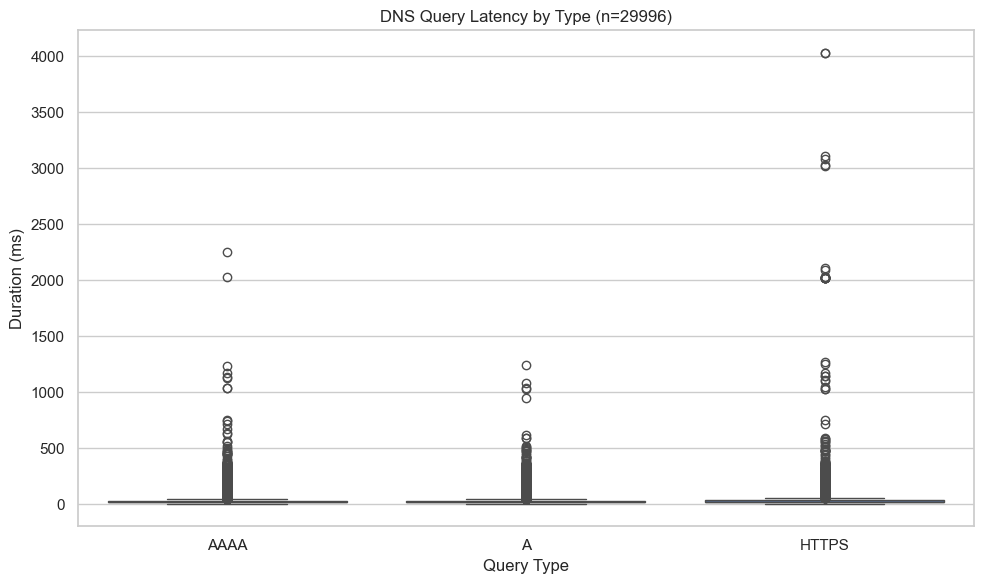

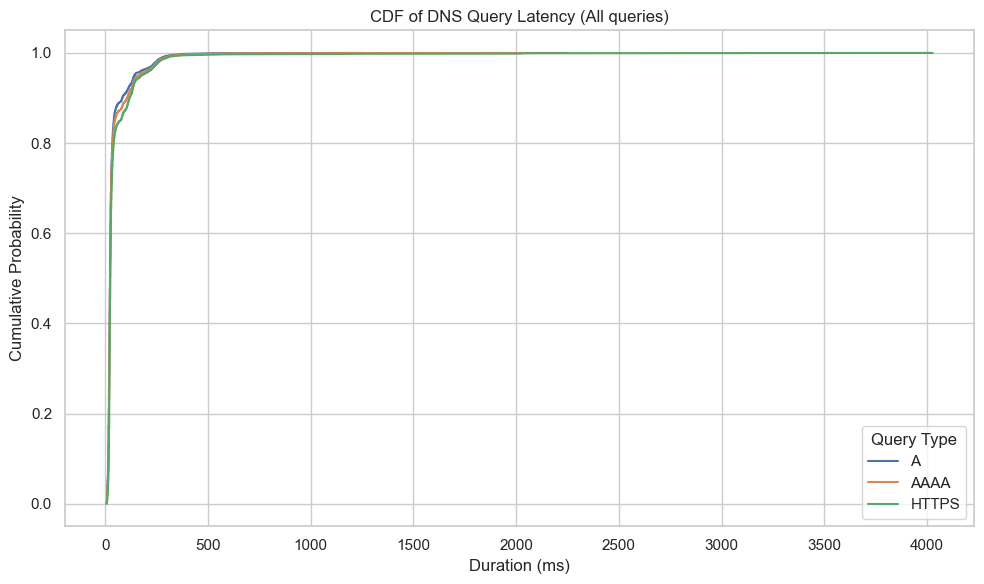

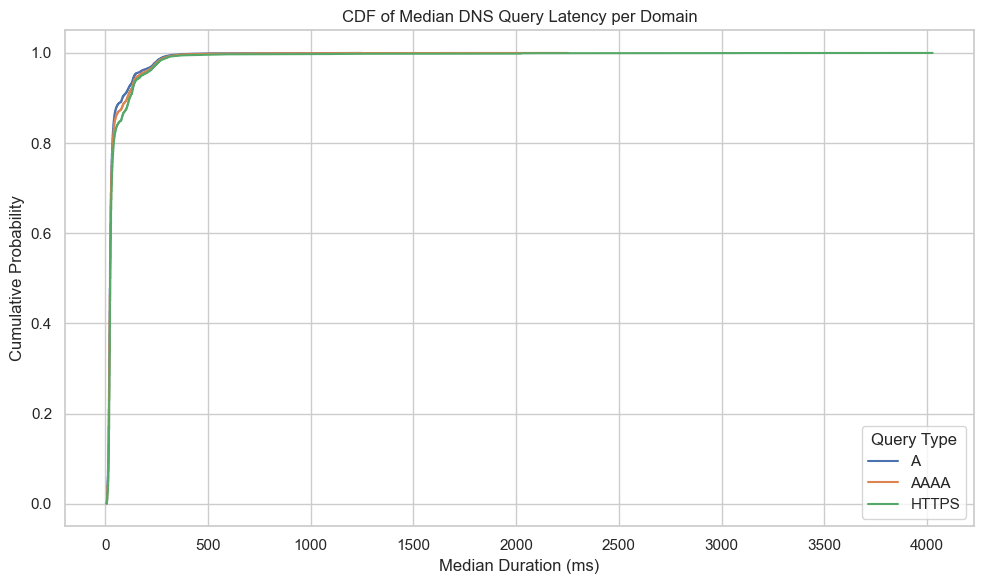


Summary Statistics of Latency (ms):


,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
A,10000.0,39.538300,57.969754,6.0,18.0,23.0,30.0,1248.0
AAAA,9999.0,43.161716,70.628313,6.0,19.0,23.0,32.0,2253.0
HTTPS,9997.0,50.888667,127.314725,7.0,20.0,24.0,35.0,4028.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Explicitly use the file generated in the previous step
latest_file = f'./results-top{topN}-n{numQueries}.csv'

if not os.path.exists(latest_file):
    raise FileNotFoundError(f"Could not find the expected results file: {latest_file}")

print(f"Loading data from: {latest_file}")

# Load the data
df = pd.read_csv(latest_file)

# Exclude failed queries (e.g. TIMEOUT)
df_success = df[df['error'].isna()].copy()
print(f"Excluded {len(df) - len(df_success)} failed queries. Proceeding with {len(df_success)} successful queries.")

# Extract number of domains and runs from filename or data
num_domains = df_success['rank'].nunique()
num_runs = df_success['run'].nunique()
print(f"Dataset contains {num_domains} unique domains and {num_runs} runs.")

# Configure aesthetics
sns.set_theme(style="whitegrid")

# 1. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_success, x='query_type', y='duration_ms')
plt.title(f'DNS Query Latency by Type (n={len(df_success)})')
plt.ylabel('Duration (ms)')
plt.xlabel('Query Type')
plt.tight_layout()
plt.show()

# 2. CDF Plot of all queries
plt.figure(figsize=(10, 6))
for qt, group in df_success.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=qt)

plt.title('CDF of DNS Query Latency (All queries)')
plt.xlabel('Duration (ms)')
plt.ylabel('Cumulative Probability')
plt.legend(title='Query Type')
plt.tight_layout()
plt.show()

# 3. CDF of median latency per domain
plt.figure(figsize=(10, 6))
median_df = df_success.groupby(['domain', 'query_type'])['duration_ms'].median().reset_index()
for qt, group in median_df.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=qt)

plt.title('CDF of Median DNS Query Latency per Domain')
plt.xlabel('Median Duration (ms)')
plt.ylabel('Cumulative Probability')
plt.legend(title='Query Type')
plt.tight_layout()
plt.show()

# Print summary statistics
summary_stats = df_success.groupby('query_type')['duration_ms'].describe()
print("\nSummary Statistics of Latency (ms):")
display(summary_stats)

## Slow Queries Analysis

The following table shows the top 20 slowest queries across all runs.

In [50]:
# Identify the slowest queries among the successful ones
slow_queries = df_success.sort_values(by='duration_ms', ascending=False).head(20)

print("\nTop 20 Slowest Successful Queries:")
display(slow_queries[['domain', 'rank', 'query_type', 'duration_ms', 'nameservers']].reset_index(drop=True))


Top 20 Slowest Successful Queries:


,domain,rank,query_type,duration_ms,nameservers
0,nih.gov,193,HTTPS,4028,"[""ns.nih.gov."",""ns2.nih.gov."",""ns3.nih.gov.""]"
1,nyc.gov,4528,HTTPS,4025,"[""ns1.nyc.gov."",""ns2.nyc.gov."",""ns3.nyc.gov."",..."
2,novell.com,4427,HTTPS,3105,"[""ns1.softwaregrp.com."",""ns2.softwaregrp.com.""..."
3,microfocus.com,5504,HTTPS,3080,"[""ns1.softwaregrp.com."",""ns2.softwaregrp.com.""..."
4,cancer.gov,4369,HTTPS,3032,"[""ns.nih.gov."",""ns2.nih.gov."",""ns3.nih.gov.""]"
5,pubmed.ncbi.nlm.nih.gov,500,HTTPS,3023,"[""dns1-ncbi.ncbi.nlm.nih.gov."",""dns2-ncbi.ncbi..."
6,oray.com,4191,AAAA,2253,"[""ns1.oray.com."",""ns2.oray.com.""]"
7,kcl.ac.uk,8988,HTTPS,2109,"[""ndc-cns-ext-01.kcl.ac.uk."",""ns3.ja.net."",""sd..."
8,boeing.com,7288,HTTPS,2092,"[""cltdnsxp01.dns.boeing.net."",""cltdnsxp02.dns...."
9,bnf.fr,7927,HTTPS,2031,"[""ariane.bnf.fr."",""galatee.bnf.fr.""]"


## Performance Impact of HTTPS RR

This analysis identifies when waiting for an HTTPS RR delays connection establishment. It calculates the latency difference between the HTTPS completion time and the fastest legacy A or AAAA response. Cases introducing >50ms delays or experiencing run-time timeouts on HTTPS specifically are grouped by the nameserver providers to identify systemic issues.

In [67]:
import json

# Start with the original df to include timeouts and errors
# Pivot durations and errors by domain and run
pivot_dur = df.pivot_table(index=['domain', 'run', 'rank'], columns='query_type', values='duration_ms', aggfunc='min').reset_index()

# Use groupby.unstack for the string 'error' column. 
# Using pivot_table on a mostly-NaN column trims the frame due to default dropna=True
pivot_err = df.groupby(['domain', 'run', 'rank', 'query_type'])['error'].first().unstack('query_type').reset_index()

# Ensure A, AAAA, and HTTPS columns exist
for qt in ['A', 'AAAA', 'HTTPS']:
    if qt not in pivot_dur.columns:
        pivot_dur[qt] = np.nan
    if qt not in pivot_err.columns:
        pivot_err[qt] = np.nan

# Calculate delay imposed by HTTPS query vs fastest legacy record
pivot_dur['min_a_aaaa'] = pivot_dur[['A', 'AAAA']].min(axis=1)
pivot_dur['https_delay'] = pivot_dur['HTTPS'] - pivot_dur['min_a_aaaa']

# Identify fail-open scenarios: where HTTPS errored/timed out but A or AAAA succeeded
pivot_err['https_error'] = pivot_err['HTTPS'].notna()
pivot_err['a_aaaa_success'] = pivot_err['A'].isna() | pivot_err['AAAA'].isna()
pivot_err['https_timeout_failopen'] = pivot_err['https_error'] & pivot_err['a_aaaa_success']

# Merge latency and error information
combined = pd.merge(pivot_dur, pivot_err[['domain', 'run', 'https_error', 'a_aaaa_success', 'https_timeout_failopen']], on=['domain', 'run'])

# Filter cases exceeding the 50ms performance threshold or timing out entirely
hurt_perf = combined[(combined['https_delay'] > 50) | combined['https_timeout_failopen']].copy()

print(f"Total domains where waiting for HTTPS hurts performance (>50ms delay or timeout): {len(hurt_perf)} out of {len(combined)}")

# Grouping worst offenders by Nameserver Providers
def extract_primary_ns(ns_str):
    try:
        ns_list = json.loads(ns_str)
        if ns_list and len(ns_list) > 0:
            ns = ns_list[0].strip('.')
            parts = ns.split('.')
            if len(parts) >= 2:
                return '.'.join(parts[-2:])
            return ns
    except:
        pass
    return "Unknown"

# Fetch nameservers from the earliest valid row per domain
domain_ns = df.dropna(subset=['nameservers']).groupby('domain')['nameservers'].first().reset_index()
domain_ns['ns_provider'] = domain_ns['nameservers'].apply(extract_primary_ns)

# Merge nameserver grouping back into the hurt_perf dataframe
hurt_perf = hurt_perf.merge(domain_ns[['domain', 'ns_provider']], on='domain', how='left')

# Output the worst nameservers 
worst_ns = hurt_perf.groupby('ns_provider').size().reset_index(name='count').sort_values(by='count', ascending=False)
print("\nTop 20 Nameserver Providers responsible for performance-hurting HTTPS responses:")
display(worst_ns.head(20).reset_index(drop=True))

# Output top specific domains 
print("\nTop 20 Specific Domains with the Highest HTTPS Delay:")
top_delayed_domains = hurt_perf.sort_values(by='https_delay', ascending=False)[['domain', 'rank', 'https_delay', 'ns_provider']].head(20).reset_index(drop=True)
display(top_delayed_domains)

Total domains where waiting for HTTPS hurts performance (>50ms delay or timeout): 847 out of 9916

Top 20 Nameserver Providers responsible for performance-hurting HTTPS responses:


,ns_provider,count
0,cloudflare.com,26
1,alidns.com,18
2,alibabadns.com,13
3,nic.ru,12
4,co.kr,12
5,googledomains.com,11
6,nic.in,11
7,akam.net,8
8,co.jp,8
9,ne.jp,8



Top 20 Specific Domains with the Highest HTTPS Delay:


,domain,rank,https_delay,ns_provider
0,pushy.io,4360,4990,pushy.me
1,iastate.edu,5264,4945,iastate.edu
2,globe.com.ph,9446,4778,com.ph
3,nih.gov,193,4016,nih.gov
4,nyc.gov,4528,4015,nyc.gov
5,novell.com,4427,3090,softwaregrp.com
6,microfocus.com,5504,3069,softwaregrp.com
7,pubmed.ncbi.nlm.nih.gov,500,3014,nih.gov
8,cancer.gov,4369,3010,nih.gov
9,boeing.com,7288,2078,boeing.net


## Total HTTPS Wait Delay Distribution

While the section above focused just on performance *hits*, let's visualize the delay that waiting for the `HTTPS` record introduced across all domains. This gives a view of whether the delay is generally around zero (resolving at the same time), negative (where HTTPS is unexpectedly faster), or significantly delayed across the board.

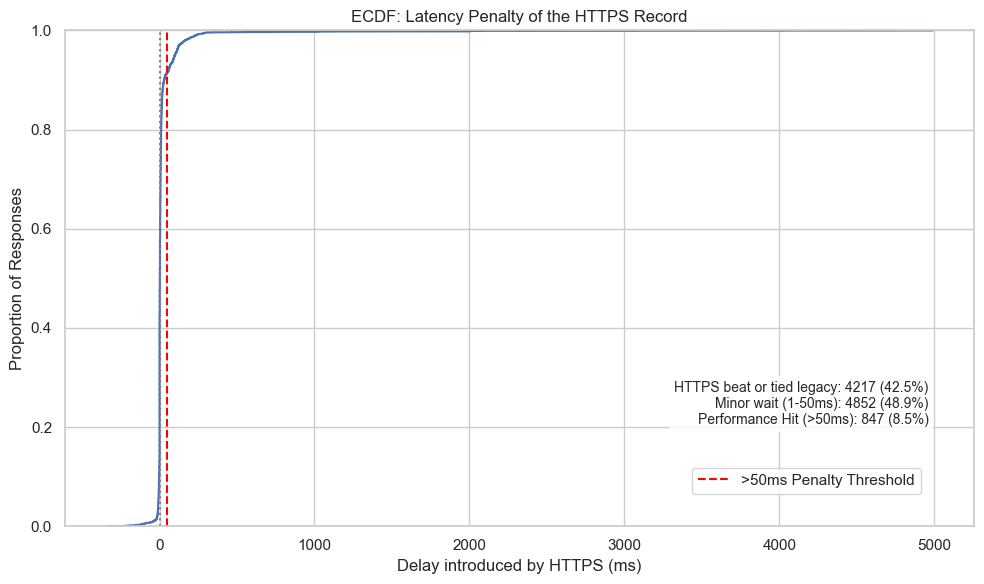

In [66]:
all_delays = combined['https_delay'].dropna()

# Empirical Cumulative Distribution Function of the general delay
plt.figure(figsize=(10, 6))
sns.ecdfplot(all_delays)
plt.title('ECDF: Latency Penalty of the HTTPS Record')
plt.xlabel('Delay introduced by HTTPS (ms)')
plt.ylabel('Proportion of Responses')
# plt.xlim(-50, 150) # Focus in on the major movement areas
plt.axvline(x=0, color='gray', linestyle=':')
plt.axvline(x=50, color='red', linestyle='--', label='>50ms Penalty Threshold')

# Calculate percentages explicitly
total_valid = len(all_delays)
pct_fast_or_same = len(all_delays[all_delays <= 0]) / total_valid * 100
pct_slow_under_50 = len(all_delays[(all_delays > 0) & (all_delays <= 50)]) / total_valid * 100
pct_hurt_perf = len(all_delays[all_delays > 50]) / total_valid * 100

stats_text = (f"HTTPS beat or tied legacy: {len(all_delays[all_delays <= 0])} ({pct_fast_or_same:.1f}%)\n"
              f"Minor wait (1-50ms): {len(all_delays[(all_delays > 0) & (all_delays <= 50)])} ({pct_slow_under_50:.1f}%)\n"
              f"Performance Hit (>50ms): {len(all_delays[all_delays > 50])} ({pct_hurt_perf:.1f}%)")

plt.text(0.95, 0.20, stats_text, 
         transform=plt.gca().transAxes, 
         fontsize=10, 
         verticalalignment='bottom', 
         horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.05))
plt.tight_layout()
plt.show()

## HTTPS Wait Delay Distribution (For domains with an HTTPS RR)

Now let's filter and look at the exact same delay distribution, but *only* for domains that actually served an `HTTPS` record successfully. Domains that return `NXDOMAIN` (no record exists) typically fail very fast and might skew the perceived performance if we are trying to measure how long a *real* HTTPS RR takes to be served.

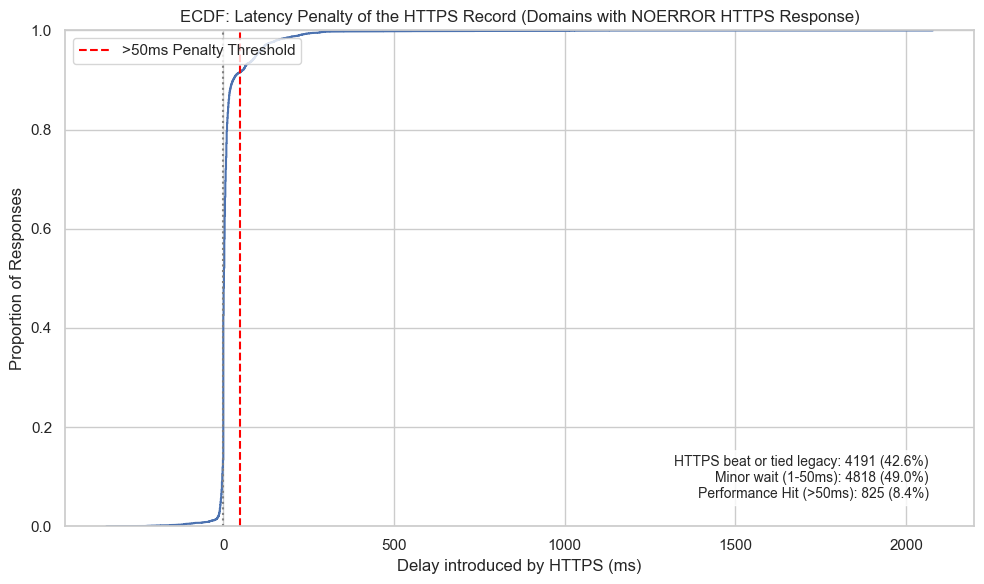

In [69]:
# Only consider rows where HTTPS queries returned successfully (NOERROR means both no timeout/dial error and no DNS error like NXDOMAIN)
https_success_domains = df[(df['query_type'] == 'HTTPS') & (df['error'].isna()) & (df['rcode'] == 'NOERROR')][['domain', 'run']]

# Filter our combined latency DataFrame down to just these known-good domains
combined_success = pd.merge(combined, https_success_domains, on=['domain', 'run'])

has_https_delays = combined_success['https_delay'].dropna()

plt.figure(figsize=(10, 6))
sns.ecdfplot(has_https_delays)
plt.title('ECDF: Latency Penalty of the HTTPS Record (Domains with NOERROR HTTPS Response)')
plt.xlabel('Delay introduced by HTTPS (ms)')
plt.ylabel('Proportion of Responses')
plt.axvline(x=0, color='gray', linestyle=':')
plt.axvline(x=50, color='red', linestyle='--', label='>50ms Penalty Threshold')

# Calculate percentages explicitly
total_valid = len(has_https_delays)
if total_valid > 0:
    pct_fast_or_same = len(has_https_delays[has_https_delays <= 0]) / total_valid * 100
    pct_slow_under_50 = len(has_https_delays[(has_https_delays > 0) & (has_https_delays <= 50)]) / total_valid * 100
    pct_hurt_perf = len(has_https_delays[has_https_delays > 50]) / total_valid * 100

    stats_text = (f"HTTPS beat or tied legacy: {len(has_https_delays[has_https_delays <= 0])} ({pct_fast_or_same:.1f}%)\n"
                f"Minor wait (1-50ms): {len(has_https_delays[(has_https_delays > 0) & (has_https_delays <= 50)])} ({pct_slow_under_50:.1f}%)\n"
                f"Performance Hit (>50ms): {len(has_https_delays[has_https_delays > 50])} ({pct_hurt_perf:.1f}%)")

    plt.text(0.95, 0.05, stats_text, 
            transform=plt.gca().transAxes, 
            fontsize=10, 
            verticalalignment='bottom', 
            horizontalalignment='right', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## The Case for HTTP/3 over QUIC (alpn=h3)

The `HTTPS` resource record provides a mechanism for servers to announce support for HTTP/3 (`h3`) over QUIC via DNS, using the `alpn` parameter. By discovering this support before initiating a connection, clients can bypass the traditional TCP and TLS handshakes, as well as the subsequent `Alt-Svc` header upgrade process.

Connecting directly via QUIC over UDP typically saves at least one full round-trip time (RTT) during connection establishment, offering noticeable latency improvements. The following analysis isolates the domains that explicitly announce `h3` support to evaluate whether the time spent waiting for the `HTTPS` record is offset by the capabilities it unlocks.

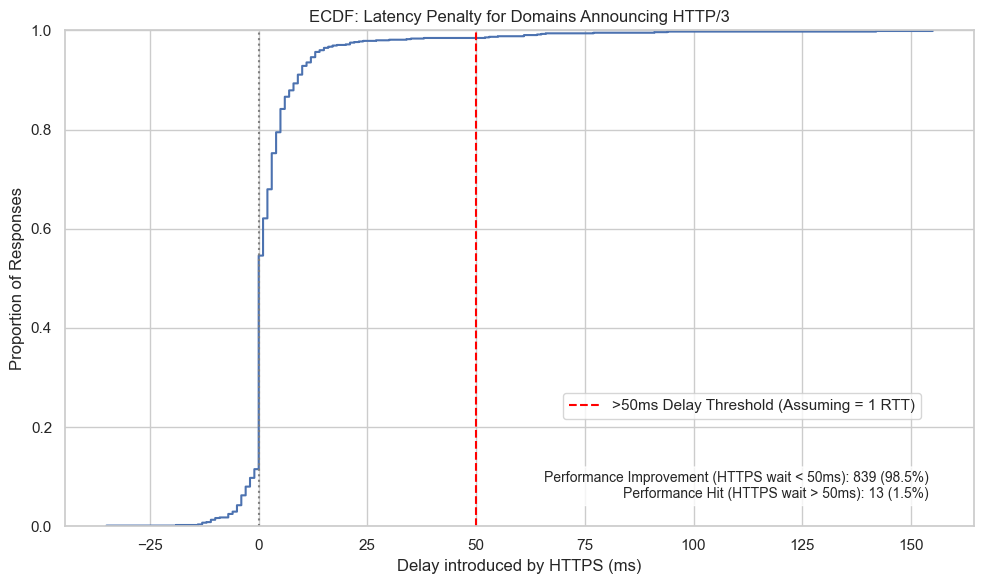

In [68]:
# Filter for domains with h3 support explicitly in their ALPN of the HTTPS RR
h3_domains = df[(df['query_type'] == 'HTTPS') & (~df['answers'].isna()) & (df['answers'].str.contains('h3', case=False, na=False))][['domain', 'run']]

combined_h3 = pd.merge(combined_success, h3_domains, on=['domain', 'run'])

h3_delays = combined_h3['https_delay'].dropna()

plt.figure(figsize=(10, 6))
sns.ecdfplot(h3_delays)
plt.title('ECDF: Latency Penalty for Domains Announcing HTTP/3')
plt.xlabel('Delay introduced by HTTPS (ms)')
plt.ylabel('Proportion of Responses')
plt.axvline(x=0, color='gray', linestyle=':')
plt.axvline(x=50, color='red', linestyle='--', label='>50ms Delay Threshold (Assuming = 1 RTT)')

# Calculate percentages explicitly around the 50ms RTT threshold
total_valid_h3 = len(h3_delays)
if total_valid_h3 > 0:
    pct_improvement = len(h3_delays[h3_delays <= 50]) / total_valid_h3 * 100
    pct_hit = len(h3_delays[h3_delays > 50]) / total_valid_h3 * 100

    stats_text_h3 = (f"Performance Improvement (HTTPS wait < 50ms): {len(h3_delays[h3_delays <= 50])} ({pct_improvement:.1f}%)\n"
                 f"Performance Hit (HTTPS wait > 50ms): {len(h3_delays[h3_delays > 50])} ({pct_hit:.1f}%)")

    plt.text(0.95, 0.05, stats_text_h3, 
             transform=plt.gca().transAxes, 
             fontsize=10, 
             verticalalignment='bottom', 
             horizontalalignment='right', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.20))
plt.tight_layout()
plt.show()